In [1]:
from raid.utils import load_data

# Download the RAID dataset with adversarial attacks included
#train_df = load_data(split="train")
#test_df = load_data(split="test")
#extra_df = load_data(split="extra")

# Download the RAID dataset without adversarial attacks
train_noadv_df = load_data(split="train", include_adversarial=False)
test_noadv_df = load_data(split="test", include_adversarial=False)
#extra_noadv_df = load_data(split="extra", include_adversarial=False)

100%|██████████| 802M/802M [01:00<00:00, 13.2MB/s] 


100%|██████████| 81.0M/81.0M [00:03<00:00, 23.7MB/s]


In [2]:
display(train_noadv_df.head())

,id,adv_source_id,source_id,model,decoding,repetition_penalty,attack,domain,title,prompt,generation
0,e5e058ce-be2b-459d-af36-32532aaba5ff,e5e058ce-be2b-459d-af36-32532aaba5ff,e5e058ce-be2b-459d-af36-32532aaba5ff,human,NaN,NaN,none,abstracts,FUTURE-AI: Guiding Principles and Consensus Re...,NaN,The recent advancements in artificial intellig...
1,f95b107b-d176-4af5-90f7-4d0bb20caf93,f95b107b-d176-4af5-90f7-4d0bb20caf93,f95b107b-d176-4af5-90f7-4d0bb20caf93,human,NaN,NaN,none,abstracts,EdgeFlow: Achieving Practical Interactive Segm...,NaN,High-quality training data play a key role in ...
2,856d8972-9e3d-4544-babc-0fe16f21e04d,856d8972-9e3d-4544-babc-0fe16f21e04d,856d8972-9e3d-4544-babc-0fe16f21e04d,human,NaN,NaN,none,abstracts,Semi-supervised Contrastive Learning for Label...,NaN,The success of deep learning methods in medica...
3,fbc8a5ea-90fa-47b8-8fa7-73dd954f1524,fbc8a5ea-90fa-47b8-8fa7-73dd954f1524,fbc8a5ea-90fa-47b8-8fa7-73dd954f1524,human,NaN,NaN,none,abstracts,Combo Loss: Handling Input and Output Imbalanc...,NaN,Simultaneous segmentation of multiple organs f...
4,72c41b8d-0069-4886-b734-a4000ffca286,72c41b8d-0069-4886-b734-a4000ffca286,72c41b8d-0069-4886-b734-a4000ffca286,human,NaN,NaN,none,abstracts,Attention-Based 3D Seismic Fault Segmentation ...,NaN,Detection faults in seismic data is a crucial ...


In [3]:
display(test_noadv_df.head())

,id,generation
0,64005577-3d63-4583-8945-7541d3e53e7d,"The Sunspot Number, created by R.Wolf in 184..."
1,c2b9df67-4e29-45ca-bdcc-7065fb907b77,We present several analogies between convex ...
2,07904f22-8530-4d3b-bf49-6bd1642d89f7,Let H be a homology theory for algebraic var...
3,dc5aa023-6f57-4f9c-833a-c0f322a994fa,"The two parallel concepts of ""small"" sets of..."
4,1b1ab19b-fe6f-458d-a666-06bbc1791534,We present new solutions to the strong explo...


In [4]:
import pandas as pd

combined_df = pd.concat([train_noadv_df, test_noadv_df], ignore_index=True)
display(combined_df.head())

,id,adv_source_id,source_id,model,decoding,repetition_penalty,attack,domain,title,prompt,generation
0,e5e058ce-be2b-459d-af36-32532aaba5ff,e5e058ce-be2b-459d-af36-32532aaba5ff,e5e058ce-be2b-459d-af36-32532aaba5ff,human,NaN,NaN,none,abstracts,FUTURE-AI: Guiding Principles and Consensus Re...,NaN,The recent advancements in artificial intellig...
1,f95b107b-d176-4af5-90f7-4d0bb20caf93,f95b107b-d176-4af5-90f7-4d0bb20caf93,f95b107b-d176-4af5-90f7-4d0bb20caf93,human,NaN,NaN,none,abstracts,EdgeFlow: Achieving Practical Interactive Segm...,NaN,High-quality training data play a key role in ...
2,856d8972-9e3d-4544-babc-0fe16f21e04d,856d8972-9e3d-4544-babc-0fe16f21e04d,856d8972-9e3d-4544-babc-0fe16f21e04d,human,NaN,NaN,none,abstracts,Semi-supervised Contrastive Learning for Label...,NaN,The success of deep learning methods in medica...
3,fbc8a5ea-90fa-47b8-8fa7-73dd954f1524,fbc8a5ea-90fa-47b8-8fa7-73dd954f1524,fbc8a5ea-90fa-47b8-8fa7-73dd954f1524,human,NaN,NaN,none,abstracts,Combo Loss: Handling Input and Output Imbalanc...,NaN,Simultaneous segmentation of multiple organs f...
4,72c41b8d-0069-4886-b734-a4000ffca286,72c41b8d-0069-4886-b734-a4000ffca286,72c41b8d-0069-4886-b734-a4000ffca286,human,NaN,NaN,none,abstracts,Attention-Based 3D Seismic Fault Segmentation ...,NaN,Detection faults in seismic data is a crucial ...


In [5]:
combined_df['generation_length'] = combined_df['generation'].apply(len)
average_generation_length = combined_df['generation_length'].mean()

print(f"The average generation length across the combined dataset is: {average_generation_length:.2f}")

The average generation length across the combined dataset is: 1422.00


In [6]:
domain_counts = combined_df['domain'].value_counts()
display(domain_counts)

domain
books        62335
news         62300
reddit       62265
wiki         62265
recipes      62020
poetry       61985
abstracts    61810
reviews      33005
Name: count, dtype: int64

In [7]:
average_length_by_label = combined_df.groupby('model')['generation_length'].mean()

print("Average generation length by content type:")
display(average_length_by_label)

Average generation length by content type:


model
chatgpt         1631.390659
cohere          1352.768604
cohere-chat     1093.565178
gpt2            1671.840831
gpt3             779.298070
gpt4            1681.696881
human           1710.813776
llama-chat      1620.792274
mistral         1479.159506
mistral-chat    1214.017557
mpt             1719.267089
mpt-chat        1060.452509
Name: generation_length, dtype: float64

In [8]:
count_by_model = combined_df['model'].value_counts()

print("Count my model:")
display(count_by_model)

Count my model:


model
llama-chat      53484
mpt             53484
mpt-chat        53484
gpt2            53484
mistral         53484
mistral-chat    53484
gpt3            26742
cohere          26742
chatgpt         26742
gpt4            26742
cohere-chat     26742
human           13371
Name: count, dtype: int64

In [ ]:
import numpy as np

for df, name in [(train_noadv_df, "Train")]:
    df['text_len'] = df['generation'].apply(len)
    df['word_count'] = df['generation'].apply(lambda x: len(x.split()))
    df['sentence_count'] = df['generation'].apply(lambda x: x.count('.') + x.count('!') + x.count('?'))
    df['avg_word_len'] = df['generation'].apply(lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0)
    df['vocab_size'] = df['generation'].apply(lambda x: len(set(x.lower().split())))
    df['type_token_ratio'] = df['vocab_size'] / df['word_count'].clip(lower=1)

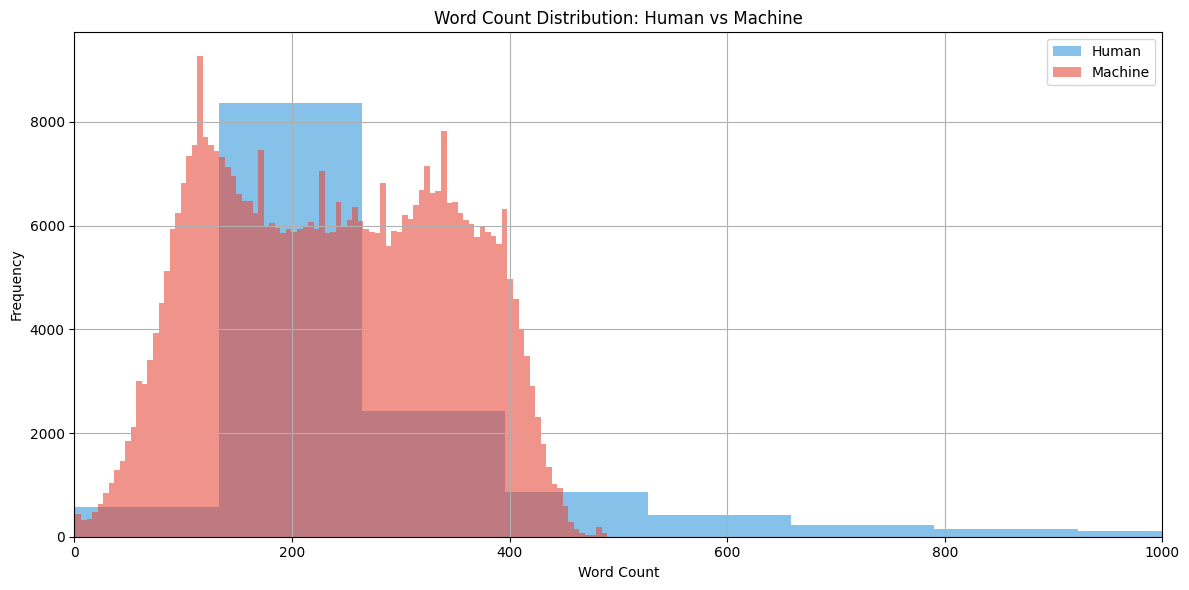

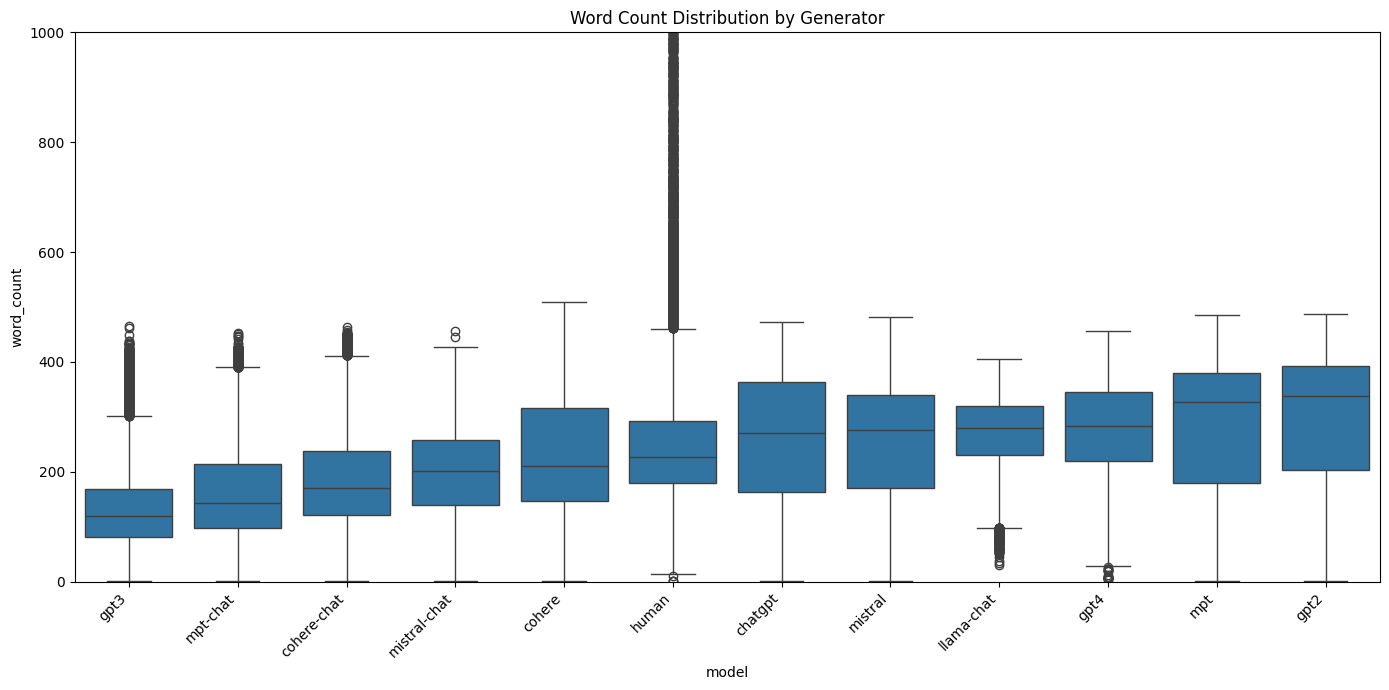

In [32]:
from matplotlib import pyplot as plt
import seaborn as sns

# vocabulary diversity
# 5a. Word count distribution: human vs machine
fig, ax = plt.subplots(figsize=(12, 6))
train_noadv_df[train_noadv_df['model'] == 'human']['word_count'].hist(
    bins=100, alpha=0.6, label='Human', color='#3498db', ax=ax)
train_noadv_df[train_noadv_df['model'] != 'human']['word_count'].hist(
    bins=100, alpha=0.6, label='Machine', color='#e74c3c', ax=ax)
ax.set_xlim(0, 1000)
ax.set_title("Word Count Distribution: Human vs Machine")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
#plt.savefig("../eda_plots/05_word_count_distribution.png", dpi=150)
plt.show()

# 5b. Word count by generator (box plot)
fig, ax = plt.subplots(figsize=(14, 7))
order = train_noadv_df.groupby('model')['word_count'].median().sort_values().index
sns.boxplot(data=train_noadv_df, x='model', y='word_count', order=order, ax=ax)
ax.set_ylim(0, 1000)
plt.xticks(rotation=45, ha='right')
ax.set_title("Word Count Distribution by Generator")
plt.tight_layout()
#plt.savefig("eda_plots/06_word_count_by_generator.png", dpi=150)
plt.show()

**Everything below this line is trying to figure out a good measure of dissimilairty between ID and OOD text.**

In [ ]:
# Everytin
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("FacebookAI/roberta-base")

/Users/rikhilrao/Documents/Programming/Classes/CS639/hw3/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
id_texts = (
    combined_df[~combined_df['model'].isin(['human', 'cohere-chat'])]
    .groupby('model')['generation']
    .head(100)
    .tolist()
)
ood_text = combined_df[combined_df['model'] == 'cohere-chat']['generation'].iloc[0]

print(f"Number of ID texts: {len(id_texts)}")
print(f"Length of OOD text: {len(ood_text)}")

Number of ID texts: 1000
Length of OOD text: 851


In [11]:
import torch
from transformers import RobertaModel

model = RobertaModel.from_pretrained("FacebookAI/roberta-base")
encoded_input_id = tokenizer(id_texts, padding=True, truncation=True, return_tensors='pt')

with torch.no_grad():
    model_output = model(**encoded_input_id)

id_embeddings = model_output.last_hidden_state.mean(dim=1)
print(f"Shape of ID embeddings: {id_embeddings.shape}")

Some weights of RobertaModel were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Shape of ID embeddings: torch.Size([1000, 768])


In [12]:
id_representative_embedding = torch.mean(id_embeddings, dim=0)
print(f"Shape of ID representative embedding: {id_representative_embedding.shape}")

Shape of ID representative embedding: torch.Size([768])


In [15]:
ood_text = combined_df[combined_df['model'] == 'human']['generation'].iloc[0]

In [16]:
encoded_input_ood = tokenizer(ood_text, padding=True, truncation=True, return_tensors='pt')

with torch.no_grad():
    model_output_ood = model(**encoded_input_ood)

ood_embedding = model_output_ood.last_hidden_state.mean(dim=1)

print(f"Shape of OOD embedding: {ood_embedding.shape}")

Shape of OOD embedding: torch.Size([1, 768])


In [17]:
import torch.nn.functional as F

cosine_sim = F.cosine_similarity(ood_embedding, id_representative_embedding.unsqueeze(0))
ood_weight = 1 - cosine_sim.item()

print(f"OOD Weight (Cosine Dissimilarity): {ood_weight}")

OOD Weight (Cosine Dissimilarity): 0.05236983299255371


**Trying to Visualize the different domains**

Loading roberta-base...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/5l/t8wj23_j3tbbty4396q12ymm0000gn/T/ipykernel_5540/1924029058.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = train_noadv_df.groupby('model').apply(


Using device: mps

Sampled 2400 texts for embedding analysis
model
chatgpt         200
cohere          200
cohere-chat     200
gpt2            200
gpt3            200
gpt4            200
human           200
llama-chat      200
mistral         200
mistral-chat    200
mpt             200
mpt-chat        200
Name: count, dtype: int64

Computing embeddings...
Processed 16/2400 samples...
Processed 176/2400 samples...
Processed 336/2400 samples...
Processed 496/2400 samples...
Processed 656/2400 samples...
Processed 816/2400 samples...
Processed 976/2400 samples...
Processed 1136/2400 samples...
Processed 1296/2400 samples...
Processed 1456/2400 samples...
Processed 1616/2400 samples...
Processed 1776/2400 samples...
Processed 1936/2400 samples...
Processed 2096/2400 samples...
Processed 2256/2400 samples...
Embedding shape: (2400, 768)
Running t-SNE...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


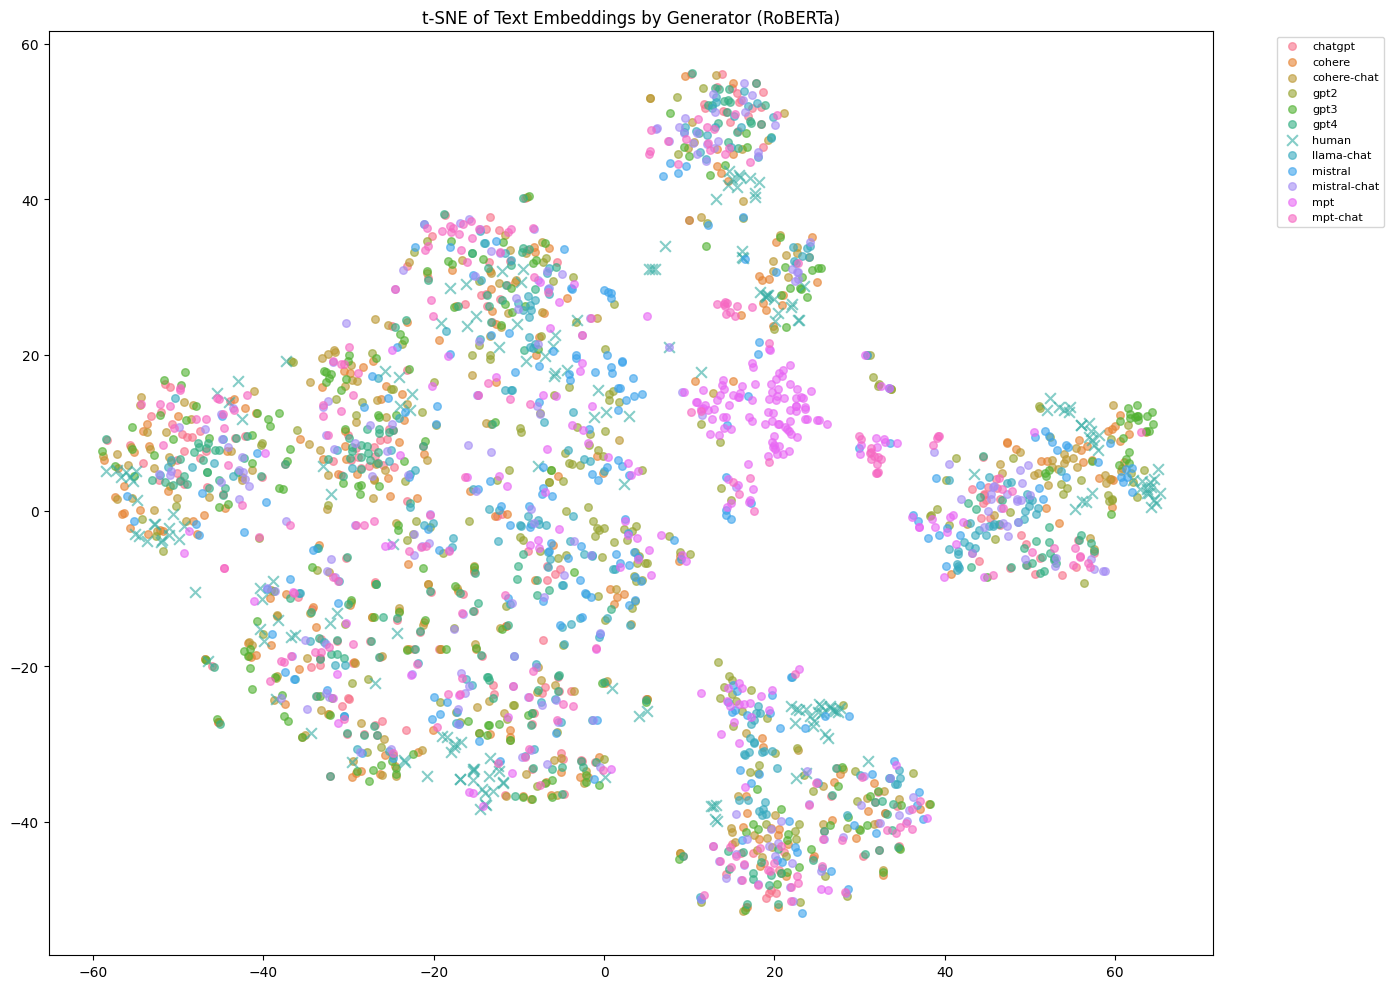

failed


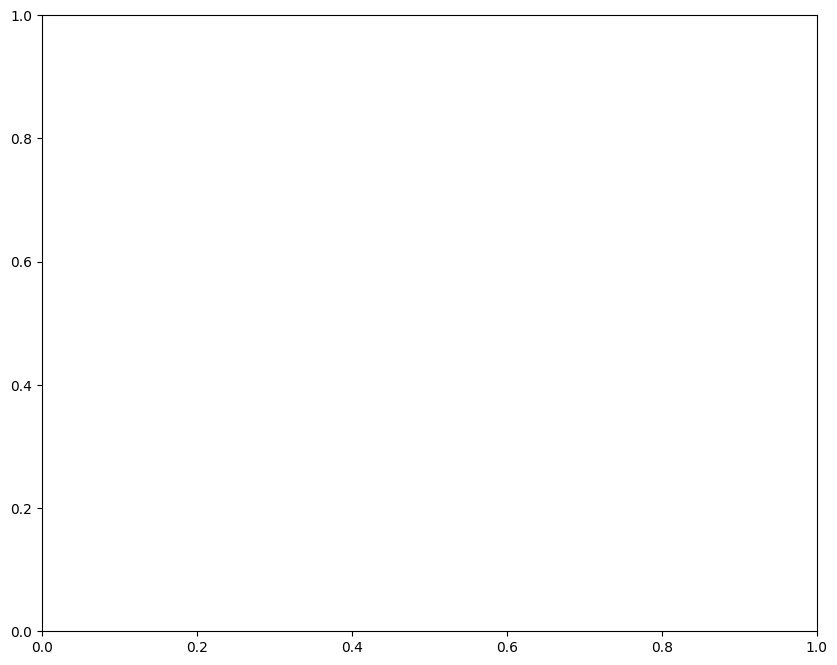

In [36]:
#embedding analysis
try:
    from transformers import AutoTokenizer, AutoModel
    import torch
    from sklearn.manifold import TSNE
    from sklearn.metrics import silhouette_score
    from scipy.spatial.distance import cdist

    model_name = "roberta-base"
    print(f"Loading {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval()

    device = torch.device("mps" if torch.backends.mps.is_available() 
                        else "cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    print(f"Using device: {device}")

    def get_embeddings(texts, batch_size=16):
        all_embeds = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(batch, padding=True, truncation=True,
                            max_length=512, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = model(**inputs)
            embeds = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeds.append(embeds)
            if (i // batch_size) % 10 == 0:
                print(f"Processed {i+len(batch)}/{len(texts)} samples...")
        return np.vstack(all_embeds)


    N_PER_CLASS = 200 # Adjust based on your compute
    sampled = train_noadv_df.groupby('model').apply(
        lambda x: x.sample(min(N_PER_CLASS, len(x)), random_state=42)
    ).reset_index(drop=True)
    print(f"\nSampled {len(sampled)} texts for embedding analysis")
    print(sampled['model'].value_counts())

    print("\nComputing embeddings...")
    embeddings = get_embeddings(sampled['generation'].tolist())
    print(f"Embedding shape: {embeddings.shape}")

    # 8a. t-SNE visualization colored by generator
    print("Running t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    coords = tsne.fit_transform(embeddings)

    fig, ax = plt.subplots(figsize=(14, 10))
    generators = sampled['model'].values
    unique_gens = sorted(set(generators))
    palette = sns.color_palette("husl", len(unique_gens))
    for i, gen in enumerate(unique_gens):
        mask = generators == gen
        marker = 'x' if gen == 'human' else 'o'
        size = 60 if gen == 'human' else 30
        ax.scatter(coords[mask, 0], coords[mask, 1],
                label=gen, alpha=0.6, s=size, marker=marker, color=palette[i])
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.set_title("t-SNE of Text Embeddings by Generator (RoBERTa)")
    plt.tight_layout()
    #plt.savefig("eda_plots/08_tsne_by_generator.png", dpi=150, bbox_inches='tight')
    plt.show()

    # 8b. t-SNE colored by human vs machine
    fig, ax = plt.subplots(figsize=(10, 8))
    labels = sampled['label'].values
    colors = ['#e74c3c' if l == 0 else '#3498db' for l in labels]
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, alpha=0.5, s=20)
    ax.scatter([], [], c='#3498db', label='Human', s=40)
    ax.scatter([], [], c='#e74c3c', label='Machine', s=40)
    ax.legend(fontsize=12)
    ax.set_title("t-SNE: Human vs Machine-Generated Text")
    plt.tight_layout()
    #plt.savefig("eda_plots/09_tsne_human_vs_machine.png", dpi=150)
    plt.show()
except:
    print("failed")